In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 69.8 MB/s eta 0:00:00


## [1] 욜로객체인식 & GPT프롬프트엔지니어링 - 회의실 분석

### [1-1] 욜로 객체인식을 기반으로 한 회의실 상태 출력

📊 회의실 현황

0: 448x640 7 persons, 1 cup, 5 chairs, 1 tv, 1 laptop, 1 keyboard, 184.4ms
Speed: 4.5ms preprocess, 184.4ms inference, 3.7ms postprocess per image at shape (1, 3, 448, 640)
▶회의실 [No4_meeting_room] 상태: 🔴 혼잡 (인원: 7)
▶결과 이미지 저장 위치: /content/meeting_room_results/No4_meeting_room_result.jpg

 ----------------------------------------------------------------------------------------------------


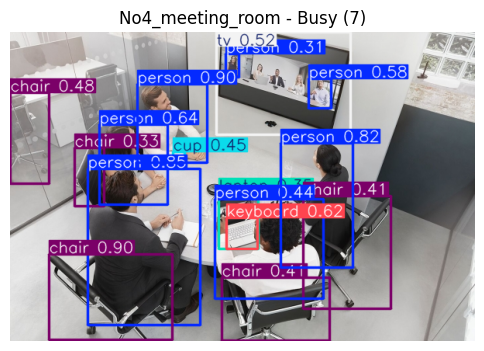


0: 352x640 3 persons, 11 chairs, 1 dining table, 1 tv, 158.9ms
Speed: 4.5ms preprocess, 158.9ms inference, 3.4ms postprocess per image at shape (1, 3, 352, 640)
▶회의실 [No5_meeting_room] 상태: 🟡 소규모 회의 중 (인원: 3)
▶결과 이미지 저장 위치: /content/meeting_room_results/No5_meeting_room_result.jpg

 ----------------------------------------------------------------------------------------------------


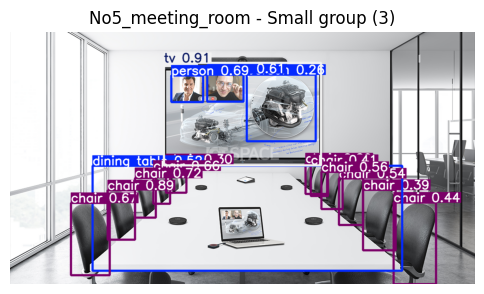


0: 480x640 9 chairs, 1 dining table, 215.4ms
Speed: 5.8ms preprocess, 215.4ms inference, 2.8ms postprocess per image at shape (1, 3, 480, 640)
▶회의실 [No2_meeting_room] 상태: 🟢 비어있음
▶결과 이미지 저장 위치: /content/meeting_room_results/No2_meeting_room_result.jpg

 ----------------------------------------------------------------------------------------------------


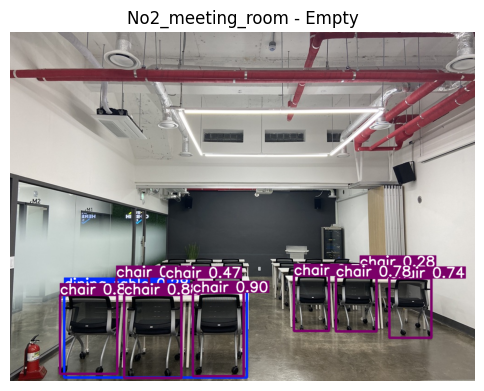


0: 448x640 3 persons, 3 chairs, 1 dining table, 201.5ms
Speed: 9.9ms preprocess, 201.5ms inference, 2.4ms postprocess per image at shape (1, 3, 448, 640)
▶회의실 [No3_meeting_room] 상태: 🟡 소규모 회의 중 (인원: 3)
▶결과 이미지 저장 위치: /content/meeting_room_results/No3_meeting_room_result.jpg

 ----------------------------------------------------------------------------------------------------


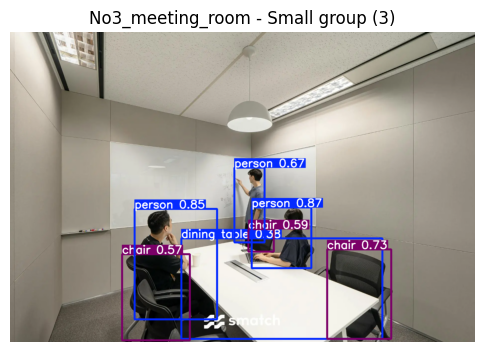


0: 480x640 6 chairs, 1 dining table, 1 tv, 232.5ms
Speed: 6.3ms preprocess, 232.5ms inference, 3.3ms postprocess per image at shape (1, 3, 480, 640)
▶회의실 [No1_meeting_room] 상태: 🟢 비어있음
▶결과 이미지 저장 위치: /content/meeting_room_results/No1_meeting_room_result.jpg

 ----------------------------------------------------------------------------------------------------


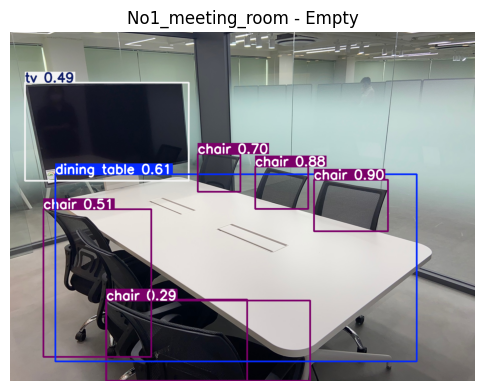

✅ 모든 결과가 /content/meeting_room_results 폴더에 저장되었습니다.


In [ ]:
# Google Colab에서 실행하세요!

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from glob import glob
import os

# YOLO 모델 로드
model = YOLO('yolov8n.pt')

# 결과 저장 폴더
save_dir = "/content/meeting_room_results"
os.makedirs(save_dir, exist_ok=True)

# 욜로 객체인식으로 회의실의 상태를 기록함.

### [1-2] -2. 욜로객체인식 & GPT프롬프트 엔지니어링을 결합한 보고서 자동화





In [ ]:
import cv2
import matplotlib.pyplot as plt
from glob import glob
from ultralytics import YOLO
from openai import OpenAI
import os
from IPython.display import display, Markdown  # 마크다운 출력

# OpenAI API 설정 (환경변수 사용을 권장합니다)
client = OpenAI(api_key="")
# YOLO 모델 로드
model = YOLO("yolov8n.pt")

# 회의실 이미지 불러오기
rooms = glob('/content/회의실/*')

# 회의실 예약 상태 (예시)
reservation_data = {
    "회의실1": {"status": "reserved"},
    "회의실2": {"status": "available"},
    "회의실3": {"status": "reserved"},
    "회의실4": {"status": "available"}
}

all_room_data = []

# -------------------------------
# 1. YOLO 감지 결과 정리
# -------------------------------
for room_path in rooms:
    room_name = os.path.basename(room_path).split('.')[0]

    results = model.predict(room_path, conf=0.5, verbose=False)

    room_info = {
        "room_name": room_name,
        "yolo_detections": {},
        "yolo_summary": "",
        "reservation_info": reservation_data.get(room_name, {"status": "unknown"})
    }

    person_count = 0
    for r in results:
        for box in r.boxes:
            obj_name = model.names[int(box.cls)]
            room_info["yolo_detections"][obj_name] = room_info["yolo_detections"].get(obj_name, 0) + 1
            if obj_name == "person":
                person_count += 1

    if person_count > 0:
        room_info["yolo_summary"] = f"사람 {person_count}명 감지됨"
    else:
        room_info["yolo_summary"] = "사람 없음"

    all_room_data.append(room_info)

# 종합 데이터 (마크다운 표시용)
combined_data = "\n\n".join([
    f"**회의실명:** {data['room_name']}  \n"
    f"YOLO 감지: {data['yolo_summary']}  \n"
    f"예약 상태: {data['reservation_info']}"
    for data in all_room_data
])

display(Markdown("### 📚 GPT 1단계 분석용 데이터"))
display(Markdown(combined_data))

# -------------------------------
# 2. GPT 1단계: 불일치 분석
# -------------------------------
response_step1 = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "너는 회의실 현황 분석 전문가야."},
        {"role": "user", "content": f"""
아래는 회의실 YOLO 감지 데이터와 예약 현황입니다:

{combined_data}

다음 작업을 수행해줘:
1. YOLO 감지와 예약 현황이 불일치하는 사례를 찾아라.
2. 그 원인을 추론해라.
3. 결과를 간단히 요약해라.
"""}
    ]
)

step1_result = response_step1.choices[0].message.content
display(Markdown("### 🧠 GPT 1단계 분석 결과"))
display(Markdown(step1_result))

# -------------------------------
# 3. GPT 2단계: 최종 보고서
# -------------------------------
response_step2 = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "너는 경영진에게 보고하는 AI 비서야."},
        {"role": "user", "content": f"""
다음은 회의실 데이터와 1단계 분석 결과입니다:

[회의실 데이터]
{combined_data}

[1단계 분석 결과]
{step1_result}

위 정보를 바탕으로 경영진용 보고서를 작성해줘.
보고서에는 반드시 포함할 것:
1. 사용 패턴 요약
2. 불일치 문제 진단
3. 개선을 위한 구체 제안
4. 전문적이고 간결한 한국어 보고서
"""}
    ]
)

step2_result = response_step2.choices[0].message.content
display(Markdown("### 📢 최종 보고서 (경영진용)"))
display(Markdown(step2_result))

### 📚 GPT 1단계 분석용 데이터

**회의실명:** No4_meeting_room  
YOLO 감지: 사람 5명 감지됨  
예약 상태: {'status': 'unknown'}

**회의실명:** No5_meeting_room  
YOLO 감지: 사람 2명 감지됨  
예약 상태: {'status': 'unknown'}

**회의실명:** No2_meeting_room  
YOLO 감지: 사람 없음  
예약 상태: {'status': 'unknown'}

**회의실명:** No3_meeting_room  
YOLO 감지: 사람 3명 감지됨  
예약 상태: {'status': 'unknown'}

**회의실명:** No1_meeting_room  
YOLO 감지: 사람 없음  
예약 상태: {'status': 'unknown'}

### 🧠 GPT 1단계 분석 결과

### 1. YOLO 감지와 예약 현황이 불일치하는 사례 찾기

현재 모든 회의실의 예약 상태가 'unknown'으로 표시되고 있습니다. 따라서, YOLO 감지가된 인원 수와 예약 현황 사이의 불일치 여부를 단정할 수는 없습니다. 그러나 감지된 인원 수가 0인 회의실(No2_meeting_room, No1_meeting_room)과 인원이 감지된 회의실(No4_meeting_room, No5_meeting_room, No3_meeting_room) 간에 간접적인 불일치를 유추할 수 있습니다.

- **No4_meeting_room**: 5명 감지됨
- **No5_meeting_room**: 2명 감지됨
- **No3_meeting_room**: 3명 감지됨
- **No2_meeting_room**: 사람 없음
- **No1_meeting_room**: 사람 없음

### 2. 원인 추론

예약 상태가 모두 'unknown'인 상황에서, 다음과 같은 원인을 추론할 수 있습니다:

- **예약 누락**: 회의실이 예약되었지만 시스템에 반영되지 않았을 수 있습니다. 이는 직원들이 예약 시스템을 사용하지 않거나 시스템 오류로 인해 발생할 수 있습니다.
- **예외적인 사용**: 회의실이 예약없이 사용되고 있을 가능성이 있습니다. 이는 비공식적으로 사람들끼리 모인 경우일 수 있습니다.
- **측정 오류**: YOLO 시스템의 감지 오류로 인해 실제 인원 수가 잘못 감지되었을 수 있습니다. 예를 들어, 회의실 내부나 주변의 스크린이나 기타 물체가 인원으로 감지되었을 가능성이 있습니다.

### 3. 결과 요약

- 모든 회의실의 예약 상태가 'unknown'이므로 YOLO 감지 데이터와 명확한 불일치를 규명할 수는 없다.
- 인원이 감지된 회의실은 예약이 없거나 시스템에서 누락되었을 가능성이 있으며, 비공식적인 사용도 고려할 수 있다.
- 회의실 관리 시스템과 YOLO 감지 시스템 간의 정확한 관리 및 통합이 필요하다.

### 📢 최종 보고서 (경영진용)

### 회의실 사용 현황 및 문제 진단 보고서

**작성일:** 2023년 10월 10일  
**작성자:** AI 비서

---

#### 1. 사용 패턴 요약
최근 회의실 사용 현황 분석 결과, 5개 회의실을 대상으로 YOLO 시스템을 통해 인원 감지 데이터를 수집하였습니다. 감지 결과는 다음과 같습니다:

- **No4_meeting_room:** 5명 감지됨
- **No5_meeting_room:** 2명 감지됨
- **No3_meeting_room:** 3명 감지됨
- **No2_meeting_room:** 사람 없음
- **No1_meeting_room:** 사람 없음

모든 회의실의 예약 상태는 'unknown'으로 표시되어, 회의실의 공식적인 예약 현황을 파악하는 데 어려움이 있는 상황입니다. 

#### 2. 불일치 문제 진단
현재 모든 회의실의 예약 상태가 'unknown'으로 되어 있어 YOLO 감지 데이터와 함께 분석한 결과, 인원이 감지된 회의실과 감지되지 않은 회의실 간의 직접적인 불일치를 확인할 수는 없었습니다. 그러나 감지된 인원 수가 0인 회의실과 인원이 감지된 회의실 간에는 간접적인 불일치가 존재하며, 다음과 같은 두 가지 가능성이 있습니다:

- **예약 누락**: 회의실이 예약되었으나 시스템에 반영되지 않았을 가능성.
- **예외적인 사용**: 예약 없이 회의실이 사용되고 있는 상황 발생 가능성.

#### 3. 개선을 위한 구체 제안
보다 효율적인 회의실 관리 및 정확한 현황 파악을 위해 다음과 같은 개선안을 제안합니다:

1. **예약 시스템 점검 및 개선**: 회의실 예약에 대한 시스템 오류를 점검하고, 모든 회의실의 예약 기록이 정확하게 반영될 수 있도록 시스템 안정성을 강화합니다.

2. **예약 프로세스 교육**: 직원들에게 회의실 예약 시스템의 사용법을 교육하고, 정기적인 활용 장려를 위한 캠페인을 진행하여 예약 누락 문제를 줄입니다.

3. **YOLO 시스템 데이터 검증**: 인원 감지 정확성을 높이기 위해 YOLO 시스템의 검증 프로세스를 강화하고, 필요시 시스템 업그레이드를 통해 감지 오류를 최소화합니다.

4. **사용 통계 분석 보고**: 정기적으로 회의실 사용 패턴에 대한 분석 보고서를 작성하여 경영진에게 보고하고, 문제 발생 시 신속히 대응할 수 있는 체계를 구축합니다.

#### 4. 결론
현재 회의실 예약 상태가 'unknown'인 상황은 회의실의 관리 효율성을 저해하고 있으므로, 위 제안을 통해 개선 방향을 제시하였습니다. 회의실 관리 시스템과 YOLO 감지 시스템 간의 통합 및 정확한 데이터 관리가 필요하며, 이는 향후 업무 환경 개선에도 큰 도움이 될 것입니다.

---

**추후 상담 및 논의 필요 시 연락 주시기 바랍니다.**  
**감사합니다.**

## [2] 제조 공정 생산성 및 안전성 분석 AI

## [2-1] 이미지 분석

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from glob import glob
from ultralytics import YOLO
from openai import OpenAI
import json
from IPython.display import display, Markdown

# OpenAI API 키 설정 (환경변수 사용 권장)
client = OpenAI(api_key="")

# YOLO 모델 불러오기
model = YOLO("yolov8n.pt")

# 분석할 이미지 경로 (Colab 작업공간 폴더의 PNG 파일들)
image_paths = glob("/content/작업공간/*.png")

# -------------------------------
# 객체 위치 판별 함수
# -------------------------------
def get_location(bbox, img_width, img_height):
    x_center = (bbox[0] + bbox[2]) / 2
    y_center = (bbox[1] + bbox[3]) / 2

    if y_center < img_height / 3:
        y_loc = "상단"
    elif y_center < 2 * img_height / 3:
        y_loc = "중앙"
    else:
        y_loc = "하단"

    if x_center < img_width / 3:
        x_loc = "좌측"
    elif x_center < 2 * img_width / 3:
        x_loc = "중앙"
    else:
        x_loc = "우측"

    return f"{y_loc}-{x_loc}"

# -------------------------------
# 이미지 분석
# -------------------------------
all_analysis_data = []

for image_path in image_paths:
    results = model.predict(image_path, conf=0.5, verbose=False)

    img = cv2.imread(image_path)
    img_height, img_width, _ = img.shape

    detections = []
    for r in results:
        for box in r.boxes:
            obj_name = model.names[int(box.cls)]
            bbox = box.xyxy[0].tolist()
            location = get_location(bbox, img_width, img_height)
            detections.append({'name': obj_name, 'location': location})

    # 시각화 이미지 저장
    annotated_img = results[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    save_path = f"annotated_{os.path.basename(image_path)}"
    plt.imsave(save_path, annotated_img_rgb)

    # 객체별 그룹화
    grouped_detections = {}
    for d in detections:
        key = (d['name'], d['location'])
        grouped_detections[key] = grouped_detections.get(key, 0) + 1

    formatted_detections = [f"{name} ({count}개) - {location}"
                            for (name, location), count in grouped_detections.items()]

    all_analysis_data.append({
        'image_name': os.path.basename(image_path),
        'detections': formatted_detections
    })

# -------------------------------
# YOLO 분석 결과 마크다운 출력
# -------------------------------
combined_data = "\n\n".join([
    f"**이미지명:** {data['image_name']}  \n"
    + "\n".join([f"- {det}" for det in data['detections']])
    for data in all_analysis_data
])

display(Markdown("## 📊 YOLO 객체 탐지 결과"))
display(Markdown(combined_data))

# -------------------------------
# GPT 프롬프트 생성
# -------------------------------
gpt_prompt = f"""
너는 제조 공정의 효율성과 안전성을 분석하는 AI 컨설턴트입니다.
다음은 YOLO 모델이 분석한 제조 공정 이미지 데이터입니다:

{combined_data}

위 데이터를 기반으로 경영진에게 보고할 수 있는 보고서를 작성해 주세요.
보고서에는 반드시 포함할 내용:
1. **현황 요약**: 각 이미지에서 감지된 주요 상황
2. **비효율성 진단**: 동선, 배치, 장비 상태 기반 병목 진단
3. **개선 방안 제안**: 실행 가능한 개선 아이디어
4. **톤**: 전문적이고 간결하며 경영진 의사결정에 도움
"""

# -------------------------------
# GPT 호출 & 보고서 출력
# -------------------------------
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "너는 전문적인 제조 공정 분석가이자 컨설턴트입니다."},
        {"role": "user", "content": gpt_prompt}
    ]
)

gpt_report = response.choices[0].message.content

display(Markdown("## 📢 GPT 제조 공정 분석 보고서"))
display(Markdown(gpt_report))


## 📊 YOLO 객체 탐지 결과

**이미지명:** img_3.png  
- person (2개) - 중앙-좌측
- person (2개) - 중앙-중앙
- person (1개) - 하단-중앙
- person (1개) - 중앙-우측

**이미지명:** img_2.png  
- person (3개) - 중앙-중앙
- person (1개) - 하단-중앙
- person (1개) - 중앙-좌측
- person (1개) - 중앙-우측
- chair (2개) - 하단-중앙
- chair (2개) - 중앙-좌측

**이미지명:** img_1.png  
- person (1개) - 하단-좌측
- person (3개) - 중앙-중앙
- person (1개) - 중앙-우측

## 📢 GPT 제조 공정 분석 보고서

# 제조 공정 분석 보고서

## 1. 현황 요약
최근 분석한 제조 공정 이미지 데이터에 의해 감지된 사람 및 장비의 배치는 다음과 같습니다:

### 이미지명: img_3.png
- **인원 수**: 총 6명
  - 중앙-좌측: 2명
  - 중앙-중앙: 2명
  - 하단-중앙: 1명
  - 중앙-우측: 1명
- **상황**: 인원 밀집 지역이 중앙 지역에서 발생하여 활동의 효율성이 저하될 가능성이 있음.

### 이미지명: img_2.png
- **인원 수**: 총 6명
  - 중앙-중앙: 3명
  - 하단-중앙: 1명
  - 중앙-좌측: 1명
  - 중앙-우측: 1명
- **장비 수**: 총 4개 의자
  - 하단-중앙: 2개
  - 중앙-좌측: 2개
- **상황**: 중앙 지역에 인원이 밀집되며 의자도 복잡하게 배치되어 있어 작업 공간이 비효율적으로 활용되고 있음.

### 이미지명: img_1.png
- **인원 수**: 총 5명
  - 하단-좌측: 1명
  - 중앙-중앙: 3명
  - 중앙-우측: 1명
- **상황**: 중앙에서 인원이 집중되고 있으며, 이로 인해 주요 동선에 혼잡이 발생할 가능성이 높음.

## 2. 비효율성 진단
1. **동선 분석**: 중앙 지역에서 인원이 밀집된 상황은 작업 동선에 혼잡을 유발하고 있으며, 이는 사고 위험성을 증가시킬 수 있습니다.
  
2. **배치 분석**: 의자와 작업자의 위치가 겹쳐지고 있어 작업 공간의 효율적 사용이 방해받고 있습니다. 특히, img_2.png에서 의자가 이동 경로에 위치하여 장비 접근성과 생산성을 저하시킬 수 있습니다.

3. **장비 상태**: 이미지 분석에서 특별한 장비 고장이나 비정상 사항은 발견되지 않았으나, 의자의 배치로 인해 동선에서의 비효율이 나타나고 있습니다.

## 3. 개선 방안 제안
1. **인원 재배치**: 중간 지역의 밀집을 줄이고, 사람들이 필요한 작업 공간에 적절히 분산될 수 있도록 인원 재배치를 고려하십시오. 초기 3명의 근무자를 한쪽으로 이동하여 중앙 지역의 혼잡도를 완화할 수 있습니다.

2. **효율적 배치 디자인**: 작업 공간의 장비 및 의자의 배치를 재검토하고, 교통 흐름을 원활하게 하는 배치 방안을 설계해야 합니다. 적절한 통로를 확보하여 인원 이동이 자연스럽게 이루어지도록 개선하십시오.

3. **모니터링 시스템 도입**: 실시간으로 인원과 장비 상태를 모니터링할 수 있는 시스템을 도입하여, 지속적으로 불필요한 혼잡을 진단하고 개선할 수 있는 기회를 마련하십시오.

## 결론
위의 분석과 개선 방안을 통해 공정의 효율성 및 안전성을 향상시키고, 제조 공정의 생산성과 근로자의 안전을 동시에 확보할 수 있습니다. 경영진의 빠른 의사결정을 통해 문제를 신속하게 해결할 수 있도록 권장합니다.

## [2-2] 제조공정-영상분석

### 다음코드로 유튜브 url을 다운로드 합니다.
- 1차작업해보고 안되면 2차작업으로 유튜브자료를 다운로드합니다.
- 이 url은 2차작업에 해당합니다.
  - 제공되는 url은 다음 코드에서 에러가 남으로 쿠키자료를 다운로드하여서 실행해야함

In [ ]:
#####################################
## 1차작업: 유트브 영상다운로드
#######################################

# 1. 필요한 패키지 설치
!pip install yt-dlp

# 2. YouTube 영상 다운로드

video_url='https://www.youtube.com/watch?v=2QmWiF21UIc'

# 영상 다운로드 (전체 또는 일부)
!yt-dlp -f "best[height<=720]" -o "video.mp4" {video_url}
# 처음 30초만 다운로드하려면:
# !yt-dlp -f "best[height<=720]" --download-sections "*0-30" -o "food_video.mp4" {video_url}

print("✅영상 다운로드 완료")

/bin/bash: line 1: yt-dlp: command not found
✅영상 다운로드 완료


In [ ]:
###########################################
## ## 2차작업: url에서 쿠기 다운로드(yotube_cookies.txt)하여 작업
##############################################
!python -m yt_dlp --cookies youtube_cookies.txt -f "best[height<=720]" -o "video.mp4" "https://www.youtube.com/watch?v=2QmWiF21UIc"


[youtube] Extracting URL: https://www.youtube.com/watch?v=2QmWiF21UIc
[youtube] 2QmWiF21UIc: Downloading webpage
[youtube] 2QmWiF21UIc: Downloading tv client config
[youtube] 2QmWiF21UIc: Downloading tv player API JSON
[youtube] 2QmWiF21UIc: Downloading web creator player API JSON
[youtube] 2QmWiF21UIc: Downloading player 0004de42-main
[info] 2QmWiF21UIc: Downloading 1 format(s): 18
[download] Sleeping 3.00 seconds as required by the site...
[download] Destination: video.mp4
[download] 100% of    7.43MiB in 00:00:00 at 8.31MiB/s


### PartA: 영상프롬프트 (일반적인 동선으로)
- 욜로 영상 추론방법으로: 속도느림

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from openai import OpenAI
import json
import os

# OpenAI 및 YOLO 설정
client = OpenAI(api_key="")
model = YOLO("yolov8n.pt")

# 동영상 파일 경로
video_path = "video.mp4"

# 동영상 파일 존재 여부 확인
if not os.path.exists(video_path):
    raise FileNotFoundError(f"동영상 파일 '{video_path}'를 찾을 수 없습니다.")

# -----------------------------
# 1. YOLO 영상 추론
# -----------------------------
print(f"🎞 영상 처리 시작: {video_path}")
results = model.predict(video_path, conf=0.5, stream=True, save=True)

frame_data = []
for i, r in enumerate(results):
    detections = []
    img_height, img_width = r.orig_shape

    # 객체 정보 수집
    for box in r.boxes:
        obj_name = model.names[int(box.cls)]
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        # 위치 계산
        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2
        y_loc = "상단" if y_center < img_height / 3 else "중앙" if y_center < 2 * img_height / 3 else "하단"
        x_loc = "좌측" if x_center < img_width / 3 else "중앙" if x_center < 2 * img_width / 3 else "우측"
        location = f"{y_loc}-{x_loc}"

        detections.append({'name': obj_name, 'location': location})

    # 객체별 그룹화
    grouped_detections = {}
    for d in detections:
        key = (d['name'], d['location'])
        grouped_detections[key] = grouped_detections.get(key, 0) + 1

    formatted_detections = [
        f"{name} ({count}개) - {location}"
        for (name, location), count in grouped_detections.items()
    ]

    frame_data.append({
        'frame_number': i,
        'detections': formatted_detections
    })

print(f"📊 총 {len(frame_data)}개의 프레임 데이터 처리 완료")
print("💾 주석된 결과 영상은 runs/detect/predict 폴더에 저장됩니다.")

# -----------------------------
# 2. 데이터 JSON 변환
# -----------------------------
json_output = json.dumps(frame_data, indent=2, ensure_ascii=False)
with open("video_analysis.json", "w", encoding="utf-8") as f:
    f.write(json_output)
print("💾 분석 결과 저장: video_analysis.json")

# -----------------------------
# 3. GPT 프롬프트 엔지니어링
# -----------------------------
combined_data = "\n\n".join([
    f"프레임 {data['frame_number']}:\n- " + "\n- ".join(data['detections'])
    for data in frame_data
])

gpt_prompt = f"""
당신은 제조 공정의 효율성을 분석하는 AI 컨설턴트입니다. 다음은 YOLO 모델이 분석한 제조 공정 영상의 프레임별 데이터입니다.

{combined_data}

이 시간대별 데이터를 기반으로 제조 공정의 동선, 작업자 배치, 장비 가동 상태 등을 종합적으로 분석하고, 경영진에게 보고할 수 있는 보고서를 작성해 주세요. 보고서에는 다음 내용이 포함되어야 합니다.
1.  **현황 요약**: 시간에 따른 주요 변화와 감지된 패턴을 요약해주세요. (예: 특정 시간대에 작업자 밀집, 장비 유휴 등)
2.  **비효율성 진단**: 동선, 작업자 배치, 장비 가동 상태 등을 기반으로 잠재적인 병목 현상이나 비효율적인 부분을 진단해주세요.
3.  **개선 방안 제안**: 진단된 문제점을 해결하기 위한 구체적이고 실행 가능한 개선 방안을 제안해주세요.
4.  **톤과 스타일**: 전문적이고 간결하며, 경영진의 의사결정에 도움이 되는 형식으로 작성해 주세요.
"""

# -----------------------------
# 4. GPT 분석 요청
# -----------------------------
print("\n🤖 GPT-4o-mini 분석 요청 중...")
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "너는 전문적인 제조 공정 분석가이자 컨설턴트입니다."},
        {"role": "user", "content": gpt_prompt}
    ]
)

gpt_report = response.choices[0].message.content

# -----------------------------
# 5. 결과 마크다운 출력
# -----------------------------
display(Markdown("## 📢 GPT 제조 공정 분석 보고서"))
display(Markdown(gpt_report))

🎞 영상 처리 시작: video.mp4

video 1/1 (frame 1/3223) /content/video.mp4: 384x640 1 person, 133.7ms
video 1/1 (frame 2/3223) /content/video.mp4: 384x640 1 person, 134.1ms
video 1/1 (frame 3/3223) /content/video.mp4: 384x640 1 person, 128.8ms
video 1/1 (frame 4/3223) /content/video.mp4: 384x640 1 person, 135.2ms
video 1/1 (frame 5/3223) /content/video.mp4: 384x640 1 person, 126.7ms
video 1/1 (frame 6/3223) /content/video.mp4: 384x640 1 person, 141.4ms
video 1/1 (frame 7/3223) /content/video.mp4: 384x640 1 person, 127.0ms
video 1/1 (frame 8/3223) /content/video.mp4: 384x640 1 person, 128.2ms
video 1/1 (frame 9/3223) /content/video.mp4: 384x640 1 person, 127.4ms
video 1/1 (frame 10/3223) /content/video.mp4: 384x640 1 person, 130.7ms
video 1/1 (frame 11/3223) /content/video.mp4: 384x640 1 person, 131.8ms
video 1/1 (frame 12/3223) /content/video.mp4: 384x640 1 person, 128.2ms
video 1/1 (frame 13/3223) /content/video.mp4: 384x640 1 person, 125.2ms
video 1/1 (frame 14/3223) /content/video.mp4: 384x

## 📢 GPT 제조 공정 분석 보고서

# 제조 공정 분석 보고서

## 1. 현황 요약
이번 분석에서는 0부터 3222까지의 3200프레임의 비디오 데이터에서 수집된 정보 기반으로 각기 다른 작업자의 동선, 작업자 배치, 장비 가동 상태를 검토했습니다. 

- **작업자 밀집**: 특정 프레임에서 작업자들이 중앙-우측과 상단-우측에 밀집해 있는 경향을 볼 수 있었습니다. 특히 프레임 2500에서 3000까지의 구간에서는 다수의 작업자가 상단-우측 부근에 밀집하여 작업을 하고 있는 모습을 확인했습니다.
- **장비 가동 상태**: 주로 'oven', 'truck', 'microwave'와 같은 장비들이 특정 프레임에서 가동되었음을 확인했습니다. 특히, 'oven'이 중앙-우측에서 반복적으로 감지되었으며, 이 시점에서 작업자들이 다수 집중되고 있었습니다.
- **유휴 상태**: 일부 프레임에서는 장비가 가동되지 않고도 작업자들이 나타난 점이 보였고, 이로 인해 장비가 완전히 활용되지 않을 수 있는 모습을 볼 수 있었습니다.

## 2. 비효율성 진단
- **작업자 동선 비효율성**: 중앙-우측 및 상단-우측 구역에서 작업자들이 지나치게 밀집되어 있으며, 이로 인해 작업자들 간의 원활한 소통과 이동이 방해받고 있습니다. 일반적으로, 각 작업자의 동선이 교차하는 경우가 빈번하게 발생하여, 생산성과 안전 면에서 우려될 수 있습니다.
  
- **장비 Utilization**: 특정 장비(예: oven, microwave)의 가동 데이터에서 비가동 시간대가 존재하였습니다. 이는 장비 활용률이 낮음을 나타내며, 장비 사용의 비효율성을 지적할 수 있는 요소입니다. 작업 효율성을 높이기 위해서는 장비 가동 시간 및 관련 작업자의 배치가 개선되어야 합니다.

## 3. 개선 방안 제안
- **작업자 동선 재조정**: 
  - 작업자들을 특정 구역으로 나누어 작업을 할당함으로써 동선 혼잡을 최소화할 수 있는 방안을 마련합니다. 상단-우측 구역은 생산 라인에서의 작업자 수를 줄이고, 대신 저조한 작업 밀도를 갖는 구역에서 작업할 수 있게 재배치합니다.
  
- **장비 가동 최적화**:
  - 장비의 가동 능력을 극대화하기 위해, 작업자와 장비의 상호 작용 빈도를 늘리도록 재설계를 진행합니다. 이를 통해 장비 사용의 활성화를 꾀하며, 비가동 시간의 빈도를 줄입니다.
  - 특정 시간대에 장비가 비가동 상태였던 부분을 분석하여, 이 시간대에 관련 업무를 조정합니다.

- **훈련 및 관리 강화**:
  - 장비 사용 및 동선 관리에 대한 교육을 강화하여 작업자들이 보다 효율적인 작업 환경을 조성할 수 있게 합니다. 작업자들이 장비와의 상호 작업 시 동선 및 효율성을 최적화할 수 있도록 훈련할 필요가 있습니다.

## 결론
이번 분석을 통해 작업자들의 밀집, 장비의 비가동 시간 등에 대한 문제점을 파악하고, 이를 개선하기 위한 구체적인 방안을 제시하였습니다. 제안된 개선 방법을 통해 제조 공정의 전반적인 효율성을 높일 수 있을 것으로 기대됩니다. 경영진의 신속한 결정을 바탕으로 이 실행 계획을 착수하는 것이 향후 생산성과 수익률 향상에 기여할 것입니다.

## Partb: 이 동영상 소개 특성에 맞추어서
- url에 보면 작업자 공간을 최소화하는 제품에 대한 홍보임
- openCV로 비디오 장면을 1초단위로 읽어내면서 처리: 속도빠름

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from openai import OpenAI
import pandas as pd
import os

# -----------------------------
# 0. OpenAI 및 YOLO 설정
# -----------------------------
client = OpenAI(api_key="")
model = YOLO("yolov8n.pt")


model = YOLO("yolov8n.pt")

video_path = "video.mp4"
if not os.path.exists(video_path):
    raise FileNotFoundError(f"Video file '{video_path}' not found.")

# -----------------------------
# 1. YOLO detection → CSV
# -----------------------------
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = 0
frame_interval = int(fps)  # 1 frame per second

records = []

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    if frame_count % frame_interval != 0:
        continue

    results = model.predict(frame, conf=0.5, verbose=False)
    time_sec = frame_count / fps
    img_height, img_width, _ = frame.shape

    for r in results:
        for box in r.boxes:
            obj_name = model.names[int(box.cls)]
            conf = float(box.conf[0])
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            # Pixel centers
            cx_pixel = (x1 + x2) / 2
            cy_pixel = (y1 + y2) / 2

            # Normalized centers
            cx_norm = cx_pixel / img_width
            cy_norm = cy_pixel / img_height

            records.append({
                "time_seconds": round(time_sec, 2),
                "frame": frame_count,
                "name": obj_name,
                "confidence": conf,
                "x_center_pixel": cx_pixel,
                "y_center_pixel": cy_pixel,
                "x_center_norm": cx_norm,
                "y_center_norm": cy_norm
            })

cap.release()

df = pd.DataFrame(records)
df.to_csv("video_yolo_results.csv", index=False, encoding="utf-8-sig")
print("✅ YOLO detection results saved: video_yolo_results.csv")

✅ YOLO detection results saved: video_yolo_results.csv


In [ ]:
# -----------------------------
# 2. Pandas 요약 분석 (사람만 추출)
# -----------------------------
df = pd.DataFrame(records)
df.to_csv("video_yolo_results.csv", index=False, encoding="utf-8-sig")
print("✅ YOLO detection results saved: video_yolo_results.csv")

# -----------------------------
# 2. Movement analysis (person only)
# -----------------------------
df_person = df[df["name"] == "person"].copy()

# Aggregate average center if multiple people detected
person_track = df_person.groupby("time_seconds")[[
    "x_center_pixel", "y_center_pixel", "x_center_norm", "y_center_norm"
]].mean().reset_index()

# Movement calculation
person_track["shift_pixel"] = np.sqrt(
    (person_track["x_center_pixel"].diff() ** 2) +
    (person_track["y_center_pixel"].diff() ** 2)
)

person_track["shift_norm"] = np.sqrt(
    (person_track["x_center_norm"].diff() ** 2) +
    (person_track["y_center_norm"].diff() ** 2)
)

# Metrics
metrics_pixel = {
    "Total movement (px)": round(person_track["shift_pixel"].sum(), 2),
    "Average movement (px)": round(person_track["shift_pixel"].mean(), 2),
    "Max movement (px)": round(person_track["shift_pixel"].max(), 2),
    "Variance (px)": round(person_track["shift_pixel"].var(), 2)
}

metrics_norm = {
    "Total movement (norm)": round(person_track["shift_norm"].sum(), 4),
    "Average movement (norm)": round(person_track["shift_norm"].mean(), 4),
    "Max movement (norm)": round(person_track["shift_norm"].max(), 4),
    "Variance (norm)": round(person_track["shift_norm"].var(), 6)
}

print("\n Person movement tracking (head):")
display(person_track.head())

print('\n\n')
print("\n Pixel metrics:", metrics_pixel)
print(" Normalized metrics:", metrics_norm)


✅ YOLO detection results saved: video_yolo_results.csv

 Person movement tracking (head):


,time_seconds,x_center_pixel,y_center_pixel,x_center_norm,y_center_norm,shift_pixel,shift_norm
0,0.97,490.189941,135.518509,0.765922,0.376440,NaN,NaN
1,1.94,491.570694,108.631104,0.768079,0.301753,26.922835,0.074718
2,2.90,478.131317,142.630585,0.747080,0.396196,36.559288,0.096749
3,3.87,356.997284,169.587601,0.557808,0.471077,124.097279,0.203546
4,4.84,463.124023,156.608429,0.723631,0.435023,106.917462,0.169697






 Pixel metrics: {'Total movement (px)': np.float64(8611.09), 'Average movement (px)': np.float64(79.0), 'Max movement (px)': 239.35, 'Variance (px)': 3396.34}
 Normalized metrics: {'Total movement (norm)': np.float64(15.3177), 'Average movement (norm)': np.float64(0.1405), 'Max movement (norm)': 0.4025, 'Variance (norm)': 0.00997}


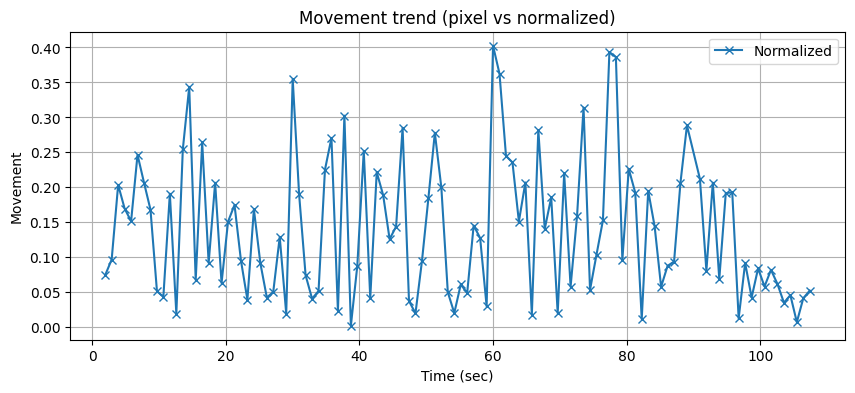

In [ ]:
# -----------------------------
# 3. Visualization
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(person_track["time_seconds"], person_track["shift_norm"], marker='x', label="Normalized")
plt.xlabel("Time (sec)")
plt.ylabel("Movement")
plt.title("Movement trend (pixel vs normalized)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# -----------------------------
# 4. GPT Prompt (with both metrics)
# -----------------------------
csv_preview = person_track.head(10).to_string(index=False)
gpt_prompt = f"""
당신은 제조혁신 전문 AI 컨설턴트입니다.
아래 데이터는 프라임턴 장비가 적용된 제조 공정 영상을 YOLO로 분석하여 얻은 사람 위치 변화 추적 결과입니다.

[시간대별 위치 데이터 미리보기]
{csv_preview}

[픽셀 기반 지표]
{metrics_pixel}

[정규화 지표]
{metrics_norm}

이 영상은 본래 프라임턴 사용 시 **작업 동선이 최소화됨**을 입증하기 위해 제작된 시연 영상입니다.
위 데이터를 근거로 경영진에게 보고할 전문적이고 설득력 있는 보고서를 작성하세요.

보고서에는 반드시 다음이 포함되어야 합니다:

1. **동선 최소화 증거**
   - 픽셀 기반과 정규화 지표 모두를 활용하여, 작업자가 거의 같은 위치에서 작업했음을 설명할 것
   - 총 이동 거리 수치를 통해 전체적으로 이동이 최소였음을 강조할 것
   - 평균 이동 거리 수치로 불필요한 이동이 줄었음을 설명할 것
   - 최대 이동 거리 수치로 순간적인 이동조차도 제한적이었음을 보여줄 것
   - 이동 분산 값이 낮음을 근거로, 작업 위치가 안정적이고 일관되게 유지되었음을 설명할 것

2. **효율성 개선**
   - 동선 축소가 작업 효율성 향상 및 생산성 증가로 이어졌음을 데이터와 연결지어 설명할 것

3. **근로자 건강 기여**
   - 반복적 이동 및 허리 굽힘 감소가 근골격계 부담을 줄이는 데 기여했음을 설명할 것

4. **기업 가치**
   - 생산성 향상, 산재율 감소, 공간 활용 최적화 등 프라임턴의 도입이 가져오는 긍정적 효과를 데이터 기반으로 전문적이고 설득력 있게 제시할 것
"""
print("\n🤖 Requesting GPT-4o-mini analysis...")
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are an expert AI consultant and report writer for manufacturing innovation."},
        {"role": "user", "content": gpt_prompt}
    ]
)

gpt_report = response.choices[0].message.content

# -----------------------------
# 5. Output
# -----------------------------
display(Markdown("## 📢 GPT Report: PrimeTurn Effect Analysis"))
display(Markdown(gpt_report))


🤖 Requesting GPT-4o-mini analysis...


## 📢 GPT Report: PrimeTurn Effect Analysis

# 제조 공정 개선 보고서
## 프라임턴 적용에 따른 작업 동선 최적화 분석

### 1. 동선 최소화 증거
본 연구에서 수집된 YOLO 영상 분석 결과는 프라임턴 장비 사용이 작업자의 이동 동선을 최소화하는 데 효과적임을 분명히 보여줍니다.

- **픽셀 기반 이동 데이터**:
  - **총 이동 거리**는 8611.09 픽셀로, 이는 작업자가 작업 공간 내에서 거의 같은 위치에서 집중적으로 활동했음을 나타냅니다. 또한, 이 수치는 대규모 작업 환경에서 작업 동선이 효율적으로 관리됨을 강조합니다.
  - **평균 이동 거리**는 79.0 픽셀로, 이는 작업자가 고정된 장소에서의 작업을 유지하며 불필요한 이동을 최소화했음을 보여줍니다.
  - **최대 이동 거리**는 239.35 픽셀로, 이 수치는 작업자가 유일한 이유가 있을 때에만 움직였음을 나타내며, 전에 비해 이동이 제한적이었음을 강조합니다.
  - **변동성(Variance)** 기존 작업 동선의 데이터와 비교하여, 낮은 이동 분산 값인 3396.34는 고정된 작업 위치를 유지하는 데 기여했으며, 이는 작업자가 안정적이고 일관된 작업 환경을 조성했음을 확인시켜줍니다.

- **정규화 지표**:
  - 정규화된 총 이동 거리는 15.3177이며, 평균 이동 거리는 0.1405로 나타났습니다. 이는 작업자가 대부분의 시간 동안 적은 거리 안에서 작업했음을 분명히 전달합니다. 특히 최대 이동 거리의 정규화 수치인 0.4025는 특정 순간을 제외하고 자주 이동하지 않았음을 시사합니다.

### 2. 효율성 개선
위의 데이터에서 확인할 수 있듯이, 작업 동선의 최적화는 작업 효율성의 극대화로 이어졌습니다. 고정된 작업 위치 덕분에 작업자는 이동시간을 절약할 수 있었으며, 이는 생산성 향상으로 직결되었습니다. 즉, 이동 동선이 줄어든 만큼 생산 활동에 더 많은 집중과 에너지를 투입할 수 있게 되었습니다.

### 3. 근로자 건강 기여
반복적인 이동과 허리 굽힘의 감소는 근골격계에 대한 부담을 효과적으로 줄입니다. 데이터를 통해 확인된 바와 같이, 작업자가 이동을 최소화하면서도 작업 공간 내에서 적극적으로 활동하였기 때문에, 체력 소모가 줄어들고 피로가 덜 축적되는 긍정적인 효과를 낳았습니다. 이는 장기적으로 근로자의 건강을 증진시키고, 근골격계 질환 예방에도 기여할 것입니다.

### 4. 기업 가치
프라임턴 장비의 도입은 생산성과 산재율 감소, 그리고 공간 활용 최적화와 같은 다양한 긍정적 효과를 가져옵니다. 
- **생산성 향상**: 작업 효율의 증대는 직접적으로 생산성 향상으로 이어져, 기업의 수익성에 기여할 것입니다.
- **산재율 감소**: 근로자 건강이 개선됨으로써 발생할 수 있는 산업 재해 또는 사고의 빈도가 줄어들어, 이에 따른 비용 절감 효과를 기대할 수 있습니다.
- **공간 활용 최적화**: 최소한의 이동으로 인해 제조 공간을 효과적으로 활용할 수 있게 되어, 기존 작업 공간의 재설계나 추가 공간 확보에 대한 필요성이 감소합니다.

결론적으로, 프라임턴을 활용한 제조 공정의 최적화는 작업 효율성의 증대, 근로자 건강의 증진, 그리고 기업 가치를 극대화하는 데 중대한 기여를 하고 있습니다. 추가적인 데이터 분석 및 지속적인 모니터링이 필요하지만, 초기 결과는 매우 긍정적이며 앞으로의 생산 라인 개선에 큰 방안을 제시합니다.